Here we provide an example of calculating the continuum effective conductivity.

We consider an infinite slab sandwiched between $(0, L_z)$.

The boundaries are Neumann, prescribing $\partial u/\partial n = 1.0$ for $-a < x < +a$ and zero everywhere else.

See also `derivation_continuum.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import scipy.integrate

In [ ]:
def u_bdry(x, a):
  ''' Explicit u along boundary for semi-infinite problem. '''
  tm = np.abs(np.abs(x) - a)
  tp = np.abs(np.abs(x) + a)
  s1 = np.zeros_like(tm)
  np.log(tm, out=s1, where=tm>0)
  s1 = tm * (s1 - 1)
  s2 = tp * (np.log(tp) - 1)
  return -1.0/np.pi * np.where(np.abs(x) < a, s2 + s1, s2 - s1)

def SL_integral(x, z, z0, a):
  ''' Single-layer potential (integration from -a to a).
  Returns the solution u on the boundary when z = z0. '''
  dz = z - z0
  # Compute 1 / dz with no warnings
  dz_inv = np.zeros_like(dz)
  np.divide(1.0, dz, where=dz != 0, out=dz_inv)
  temp = (x - a) * np.log((x - a)*(x - a) + dz*dz) \
    - (x + a) * np.log((x + a)*(x + a) + dz*dz) \
    + 2 * dz * (np.arctan((x - a) * dz_inv) - np.arctan((x + a) * dz_inv)) + 4 * a
  # Use u bdry solution for limit dz = 0
  return np.where(dz != 0,  0.25 / np.pi * temp, 0.5 * u_bdry(x, a))

def U(x, z, num_images:int, a=1.0, L_z=10.0):
  ''' Semi-infinite solution. '''
  u = np.zeros(x.shape)
  next_sign = 1.0
  for img_idx in range(num_images):
    u += 2.0 * next_sign * ( # Factor of 2 for SL - DL, where DL == -SL
      SL_integral(x, z, (-img_idx)*L_z, a)
      - SL_integral(x, z, (img_idx+1)*L_z, a))
    next_sign *= -1.0   
  return u

a/L = 0.03333333333333333
Average conductivity = 0.4209046361635568


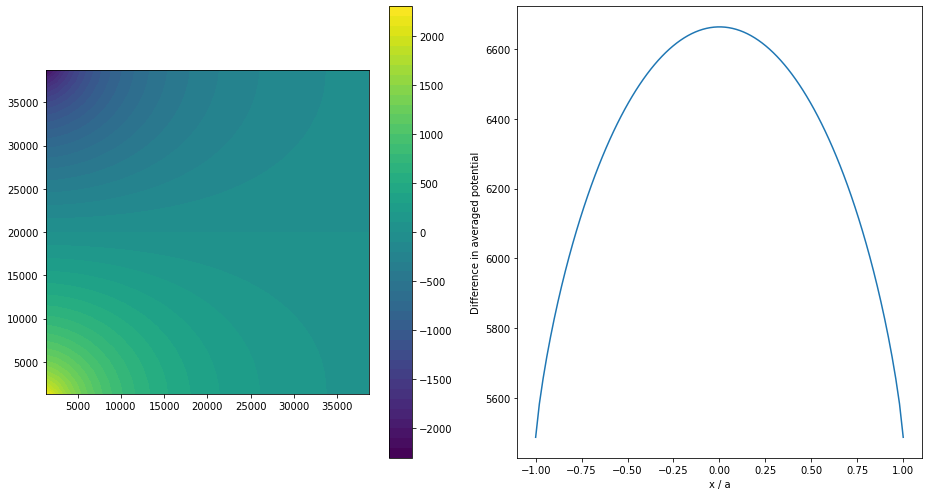

In [7]:
# Specific calculation
L_z = 40000
N = 30
eps = 1e-7
num_images = 20
N_sample = 100
# Compute finite aperture
a = L_z / N

# Evaluate field for plotting
x_viz_range = np.linspace(0, L_z, 32)[1:-1]
z_viz_range = np.linspace(0, L_z, 32)[1:-1]
mg_x, mg_z = np.meshgrid(x_viz_range, z_viz_range)

mg_u = U(mg_x, mg_z, num_images, a=a, L_z=L_z) # + U(mg_x - 2 * L_z, mg_z, 10, a=a, L_z=L_z)

plt.figure(figsize=(13,7))
plt.subplot(1,2,1)
plt.contourf(mg_x, mg_z, mg_u, levels=50)
plt.colorbar()
plt.gca().set_aspect("equal")

# Use symmetry to compute potential difference between boundaries; average over aperture
x_vec_on_bdry = np.linspace(-a, a, N_sample)
z_vec_on_bdry = eps * L_z * np.ones_like(x_vec_on_bdry)
# Build trapezoid quadrature covector
integ_vec = np.ones_like(x_vec_on_bdry) * (x_vec_on_bdry[1] - x_vec_on_bdry[0])
integ_vec[0] *= 0.5
integ_vec[-1] *= 0.5

# Evaluate potential diff
u_terminals_in = U(x_vec_on_bdry, z_vec_on_bdry, num_images, a=a, L_z=L_z)
u_terminals_out = U(x_vec_on_bdry, L_z - z_vec_on_bdry, num_images, a=a, L_z=L_z)
potential_diff = (u_terminals_in - u_terminals_out)
# Compute average
V_avg = np.dot(integ_vec, potential_diff) / (2 * a)

plt.subplot(1,2,2)
plt.plot(x_vec_on_bdry/a, potential_diff)
plt.xlabel("x / a")
plt.ylabel("Difference in averaged potential")

plt.tight_layout()

print(f"a/L = {a/L_z}")
print(f"Average conductivity = {(2 * a / V_avg)}")

In [8]:
# N sweep
N_range = np.linspace(1.5, 120, 256)
V_range_slab = np.zeros_like(N_range, dtype=float)
V_range_bounded = np.zeros_like(N_range, dtype=float)
V_range_min = np.zeros_like(N_range, dtype=float)
V_range_max = np.zeros_like(N_range, dtype=float)

L_z = 40000
N_sample = 8
num_images = 100
eps = 0.0

for i, N in enumerate(N_range):
  a = 0.5 * L_z / (N-1)

  x_vec_on_bdry = np.linspace(-a, a, N_sample)
  z_vec_on_bdry = eps * L_z * np.ones_like(x_vec_on_bdry)
  # Build trapezoid quadrature covector
  integ_vec = np.ones_like(x_vec_on_bdry) * (x_vec_on_bdry[1] - x_vec_on_bdry[0])
  integ_vec[0] *= 0.5
  integ_vec[-1] *= 0.5

  # Evaluate potential diff
  potential_diff = 2 * U(x_vec_on_bdry, z_vec_on_bdry, num_images, a=a, L_z=L_z)
  # Evaluate bounded version
  lat_images = 3
  potential_diff_bounded = potential_diff.copy()
  for lat_idx in range(lat_images):
    potential_diff_bounded += 2 * (
      U(x_vec_on_bdry - 2 * L_z, z_vec_on_bdry, num_images, a, L_z)
      + U(x_vec_on_bdry + 2 * L_z, z_vec_on_bdry, num_images, a, L_z))

  V_range_slab[i] = np.dot(integ_vec, potential_diff)
  V_range_bounded[i] = np.dot(integ_vec, potential_diff_bounded)
  V_range_max[i] = potential_diff.max()
  V_range_min[i] = potential_diff.min()

C:\Users\Fredric\AppData\Local\Temp\ipykernel_20628\3873831360.py:18: RuntimeWarning: divide by zero encountered in log
  temp = (x - a) * np.log((x - a)*(x - a) + dz*dz) \
C:\Users\Fredric\AppData\Local\Temp\ipykernel_20628\3873831360.py:18: RuntimeWarning: invalid value encountered in multiply
  temp = (x - a) * np.log((x - a)*(x - a) + dz*dz) \
C:\Users\Fredric\AppData\Local\Temp\ipykernel_20628\3873831360.py:19: RuntimeWarning: divide by zero encountered in log
  - (x + a) * np.log((x + a)*(x + a) + dz*dz) \
C:\Users\Fredric\AppData\Local\Temp\ipykernel_20628\3873831360.py:19: RuntimeWarning: invalid value encountered in multiply
  - (x + a) * np.log((x + a)*(x + a) + dz*dz) \


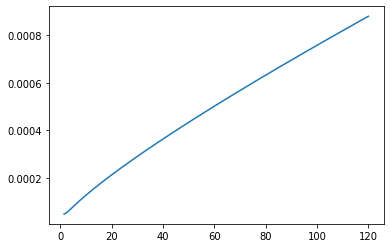

In [9]:
plt.plot(N_range, 1/V_range_min)
